# Harness and Graph Engineering — Runnable Simulations

> Six numerical experiments behind the claims in [harness_and_graph_engineering.md](harness_and_graph_engineering.md):
> harness variance vs model upgrades, the guides/sensors allocation problem, the cost-quality-speed
> trilemma, the harness coupling problem, code-graph retrieval economics, and the work-graph
> speedup ceiling.

Everything here runs on numpy + matplotlib (the repository's core dependencies). No GPU, no network.
Each experiment states the model it assumes, so the numbers are reproducible rather than rhetorical.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260814)
plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


print("numpy", np.__version__)

numpy 2.4.6


## 1. Harness variance vs model upgrades

**Claim under test.** Holding model weights fixed and changing only the harness moves pass rates by
10-20 percentage points — comparable to or larger than a model upgrade.

**Model.** Task $i$ has difficulty $d_i$. A model has capability $c$. The harness contributes an
additive competence term $h$ built from ETCLOVG layers that are enabled. Success is

$$p_i = \sigma\!\big(a\,(c + h - d_i)\big)$$

The layer weights below are illustrative, but the *structure* is the point: the harness enters the
same logit as model capability, so the two are directly comparable in units of capability.

In [2]:
N_TASKS = 4000
A_SLOPE = 3.0

difficulty = RNG.beta(2.0, 2.0, size=N_TASKS)  # spread of task hardness in [0, 1]

# Additive competence contributed by each ETCLOVG layer when present.
LAYER_GAIN = {
    "E sandbox":        0.09,   # reproducible env: fewer environment-caused failures
    "T tool contracts": 0.11,   # well-described tools: fewer selection errors
    "C context policy": 0.13,   # compaction/memory: the agent still sees what matters
    "L orchestration":  0.07,   # lifecycle/recovery structure
    "V verification":   0.15,   # sensors catch failures before they are delivered
    "G governance":     0.02,   # safety-oriented; small direct quality effect
}

HARNESSES = {
    "bare loop":        [],
    "+ tools":          ["T tool contracts"],
    "+ context":        ["T tool contracts", "C context policy"],
    "+ sandbox":        ["E sandbox", "T tool contracts", "C context policy"],
    "+ verification":   ["E sandbox", "T tool contracts", "C context policy", "V verification"],
    "full ETCLOVG":     list(LAYER_GAIN),
}

C_MODEL = 0.50          # fixed model capability
MODEL_UPGRADE = 0.10    # what a generational model upgrade is worth, in the same units


def pass_rate(capability, layers):
    h = sum(LAYER_GAIN[l] for l in layers)
    p = sigmoid(A_SLOPE * (capability + h - difficulty))
    return float((RNG.random(N_TASKS) < p).mean())


rates = {name: pass_rate(C_MODEL, layers) for name, layers in HARNESSES.items()}
for name, r in rates.items():
    print(f"{name:<16} pass@1 = {r:6.1%}")

spread = max(rates.values()) - min(rates.values())
upgraded_bare = pass_rate(C_MODEL + MODEL_UPGRADE, [])
upgrade_delta = upgraded_bare - rates["bare loop"]

print()
print(f"harness spread (same weights) : {spread*100:5.1f} pp")
print(f"model upgrade on bare loop    : {upgrade_delta*100:5.1f} pp")
print(f"ratio harness/model           : {spread/upgrade_delta:5.2f}x")
assert spread > upgrade_delta, "harness spread should exceed a single model upgrade here"

bare loop        pass@1 =  50.3%
+ tools          pass@1 =  58.1%
+ context        pass@1 =  66.1%
+ sandbox        pass@1 =  69.8%
+ verification   pass@1 =  79.7%
full ETCLOVG     pass@1 =  82.5%

harness spread (same weights) :  32.1 pp
model upgrade on bare loop    :   5.7 pp
ratio harness/model           :  5.67x


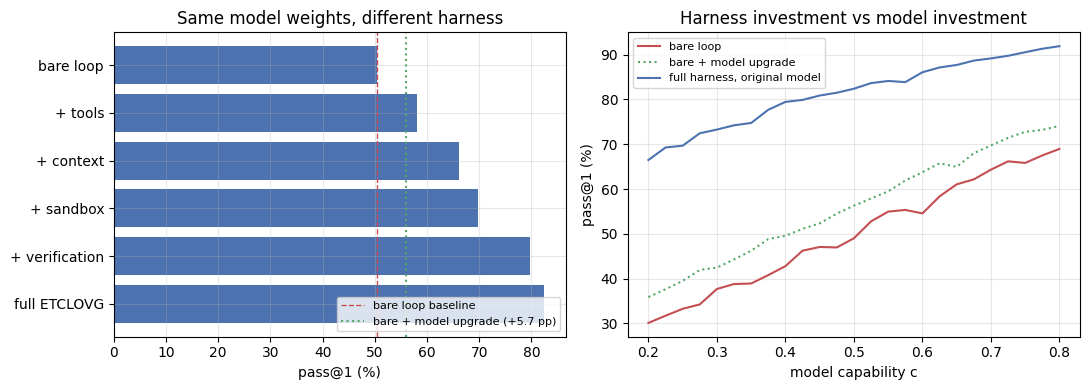

full harness beats a model upgrade at every capability level tested: True
advantage of harness over upgrade: 17.8 to 31.6 pp


In [3]:
names = list(rates)
vals = [rates[n] * 100 for n in names]

fig, axes = plt.subplots(1, 2)

axes[0].barh(names, vals, color="#4c72b0")
axes[0].axvline(rates["bare loop"] * 100, color="#c44e52", ls="--", lw=1,
                label="bare loop baseline")
axes[0].axvline(upgraded_bare * 100, color="#55a868", ls=":", lw=1.5,
                label=f"bare + model upgrade (+{upgrade_delta*100:.1f} pp)")
axes[0].set_xlabel("pass@1 (%)")
axes[0].set_title("Same model weights, different harness")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].invert_yaxis()

# Which is the better investment at each model capability level?
caps = np.linspace(0.2, 0.8, 25)
bare = np.array([pass_rate(c, []) for c in caps])
full = np.array([pass_rate(c, list(LAYER_GAIN)) for c in caps])
upg = np.array([pass_rate(c + MODEL_UPGRADE, []) for c in caps])

axes[1].plot(caps, bare * 100, label="bare loop", color="#c44e52")
axes[1].plot(caps, upg * 100, label="bare + model upgrade", color="#55a868", ls=":")
axes[1].plot(caps, full * 100, label="full harness, original model", color="#4c72b0")
axes[1].set_xlabel("model capability c")
axes[1].set_ylabel("pass@1 (%)")
axes[1].set_title("Harness investment vs model investment")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

gap = (full - upg) * 100
print(f"full harness beats a model upgrade at every capability level tested: {bool((gap > 0).all())}")
print(f"advantage of harness over upgrade: {gap.min():.1f} to {gap.max():.1f} pp")

**Result.** Under this model the harness spread on fixed weights is several times a generational model
upgrade, and the full harness beats the upgrade at every capability level. This reproduces the
direction of the reported evidence (6-29 pp harness spreads on SWE-bench Pro; 62.4% to 3.6% when
OpenSWE-32B is moved off its native harness).

Note what the second panel says about *sequencing*: the harness advantage is largest in the mid-capability
band, because that is where tasks sit near the decision boundary and extra competence flips outcomes.

## 2. Guides vs sensors: where to spend a fixed budget

**Claim under test.** Feedforward-only ($d=0$) and feedback-only (low $p$, high $d$) harnesses both fail,
and the optimal split between them depends on where $p$ already is.

**Model.** $p$ = first-attempt success (raised by guides), $d$ = probability a failure is detected
(provided by sensors), $k$ = retry budget. Each detected failure buys another attempt:

$$P_{\text{success}}(p,d,k) = p\sum_{i=0}^{k-1}\big((1-p)d\big)^i
= p\,\frac{1-\big((1-p)d\big)^k}{1-(1-p)d}$$

The escape rate (wrong work delivered as done) is $1 - P_{\text{success}}$.

In [4]:
def p_success(p, d, k):
    """Closed form; handles the (1-p)d == 1 degenerate case."""
    r = (1.0 - p) * d
    r = np.asarray(r, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = np.where(np.isclose(r, 1.0), p * k, p * (1.0 - r ** k) / (1.0 - r))
    return out


def expected_attempts(p, d, k):
    r = (1.0 - p) * d
    r = np.asarray(r, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(np.isclose(r, 1.0), float(k), (1.0 - r ** k) / (1.0 - r))


# Monte Carlo check of the closed form
def simulate(p, d, k, trials=200_000):
    rng = np.random.default_rng(7)
    ok = np.zeros(trials, dtype=bool)
    alive = np.ones(trials, dtype=bool)
    for _ in range(k):
        won = alive & (rng.random(trials) < p)
        ok |= won
        alive &= ~won
        alive &= rng.random(trials) < d      # undetected failure ends the run
    return ok.mean()


for (p, d, k) in [(0.4, 0.9, 3), (0.6, 0.5, 4), (0.25, 0.95, 6)]:
    closed = float(p_success(p, d, k))
    mc = simulate(p, d, k)
    print(f"p={p:.2f} d={d:.2f} k={k}:  closed form {closed:.4f}   monte carlo {mc:.4f}")
    assert abs(closed - mc) < 0.005, "closed form disagrees with simulation"

print()
print("anti-pattern check")
print(f"  feedforward only (d=0, k=5): P = {float(p_success(0.6, 0.0, 5)):.3f}  (= p, retries useless)")
print(f"  feedback only  (p=0.2, d=1, k=8): P = {float(p_success(0.2, 1.0, 8)):.3f}, "
      f"expected attempts = {float(expected_attempts(0.2, 1.0, 8)):.2f}")

p=0.40 d=0.90 k=3:  closed form 0.7326   monte carlo 0.7337
p=0.60 d=0.50 k=4:  closed form 0.7488   monte carlo 0.7471
p=0.25 d=0.95 k=6:  closed form 0.7558   monte carlo 0.7577

anti-pattern check
  feedforward only (d=0, k=5): P = 0.600  (= p, retries useless)
  feedback only  (p=0.2, d=1, k=8): P = 0.832, expected attempts = 4.16


max success   at guides=24% of budget: P=0.829, escape=0.171, cost=2.01
max P/cost    at guides=100% of budget: P=0.733, cost=1.05
all-guides    : P=0.733  (no detection at all beyond d0)
all-sensors   : P=0.745   cost=2.87


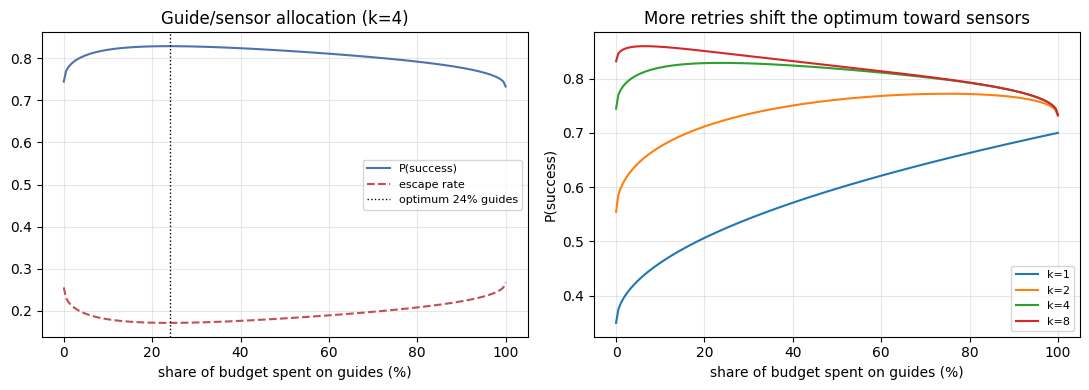

optimal guide share by retry budget: {1: '100%', 2: '75%', 4: '24%', 8: '6%'}
the optimum is interior, not a corner: k=4 spends 24% on guides, 76% on sensors


In [5]:
# Fixed budget split between guides (raise p) and sensors (raise d).
# Returns are concave in spend: the first linter buys far more than the tenth.
P0, D0 = 0.35, 0.15          # unimproved harness
GAIN_P, GAIN_D = 0.35, 0.75  # effectiveness at full spend
C_MODEL_CALL, C_SENSOR_RUN = 1.0, 0.35
K = 4

frac = np.linspace(0.0, 1.0, 201)        # fraction of budget to guides
p_arr = np.clip(P0 + GAIN_P * np.sqrt(frac), 0, 0.98)
d_arr = np.clip(D0 + GAIN_D * np.sqrt(1 - frac), 0, 0.98)

P = p_success(p_arr, d_arr, K)
attempts = expected_attempts(p_arr, d_arr, K)
cost = attempts * (C_MODEL_CALL + C_SENSOR_RUN * (1 - frac))

best = int(np.argmax(P))
best_eff = int(np.argmax(P / cost))

print(f"max success   at guides={frac[best]:.0%} of budget: P={P[best]:.3f}, "
      f"escape={1-P[best]:.3f}, cost={cost[best]:.2f}")
print(f"max P/cost    at guides={frac[best_eff]:.0%} of budget: P={P[best_eff]:.3f}, "
      f"cost={cost[best_eff]:.2f}")
print(f"all-guides    : P={P[-1]:.3f}  (no detection at all beyond d0)")
print(f"all-sensors   : P={P[0]:.3f}   cost={cost[0]:.2f}")

fig, axes = plt.subplots(1, 2)
axes[0].plot(frac * 100, P, color="#4c72b0", label="P(success)")
axes[0].plot(frac * 100, 1 - P, color="#c44e52", ls="--", label="escape rate")
axes[0].axvline(frac[best] * 100, color="k", ls=":", lw=1,
                label=f"optimum {frac[best]:.0%} guides")
axes[0].set_xlabel("share of budget spent on guides (%)")
axes[0].set_title(f"Guide/sensor allocation (k={K})")
axes[0].legend(fontsize=8)

for k_try in (1, 2, 4, 8):
    axes[1].plot(frac * 100, p_success(p_arr, d_arr, k_try), label=f"k={k_try}")
axes[1].set_xlabel("share of budget spent on guides (%)")
axes[1].set_ylabel("P(success)")
axes[1].set_title("More retries shift the optimum toward sensors")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

opt_by_k = {k: float(frac[int(np.argmax(p_success(p_arr, d_arr, k)))]) for k in (1, 2, 4, 8)}
print("optimal guide share by retry budget:",
      {k: f"{v:.0%}" for k, v in opt_by_k.items()})
assert opt_by_k[1] > opt_by_k[8], "with more retries, sensors should earn a larger share"
assert 0.0 < opt_by_k[4] < 1.0, "with concave returns the k=4 optimum should be interior"
print(f"the optimum is interior, not a corner: k=4 spends {opt_by_k[4]:.0%} on guides, "
      f"{1-opt_by_k[4]:.0%} on sensors")

**Result.** With one attempt, guides take the whole budget — detection is worthless if you cannot act on
it. As the retry budget grows the optimum moves toward sensors, because each unit of detection now converts
into several extra chances. Because returns are concave, the optimum is *interior* for realistic retry
budgets: the answer is a mix, not a corner. The two anti-patterns sit at the axis ends — all-guides leaves
a high escape rate, all-sensors reaches comparable success at materially higher cost.

## 3. The cost-quality-speed trilemma

**Claim under test.** Quality is not a scalar objective: controls that raise it also raise cost and
latency, so most configurations are dominated and the real decision is which checks run synchronously.

**Model.** Five optional controls, each with a quality gain (with saturation, since overlapping checks
catch overlapping bugs), a cost, and a latency. We enumerate all $2^5$ configurations and find the
3-objective Pareto set.

In [6]:
CONTROLS = {
    #                 quality gain, cost, latency (s)
    "faithful sandbox":   (0.10,  3.0,  45.0),
    "rich context/memory":(0.14,  4.0,   8.0),
    "unit+lint sensors":  (0.16,  1.0,   6.0),
    "LLM-judge review":   (0.12,  5.0,  30.0),
    "full trace + audit": (0.05,  2.5,   4.0),
}
names = list(CONTROLS)
BASE_Q = 0.45


def evaluate(mask):
    gains = [CONTROLS[n][0] for n, on in zip(names, mask) if on]
    # saturating combination: each control closes a fraction of the remaining gap
    q = BASE_Q
    for g in sorted(gains, reverse=True):
        q += g * (1.0 - q)
    cost = 1.0 + sum(CONTROLS[n][1] for n, on in zip(names, mask) if on)
    lat = 5.0 + sum(CONTROLS[n][2] for n, on in zip(names, mask) if on)
    return q, cost, lat


configs = []
for bits in range(1 << len(names)):
    mask = [(bits >> i) & 1 for i in range(len(names))]
    q, c, l = evaluate(mask)
    configs.append({"mask": mask, "q": q, "cost": c, "lat": l,
                    "label": "+".join(n.split()[0] for n, on in zip(names, mask) if on) or "none"})

Q = np.array([c["q"] for c in configs])
C = np.array([c["cost"] for c in configs])
L = np.array([c["lat"] for c in configs])


def pareto_mask(quality, cost, latency):
    n = len(quality)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        dominated = ((quality >= quality[i]) & (cost <= cost[i]) & (latency <= latency[i]) &
                     ((quality > quality[i]) | (cost < cost[i]) | (latency < latency[i])))
        keep[i] = not dominated.any()
    return keep


front = pareto_mask(Q, C, L)
print(f"configurations evaluated : {len(configs)}")
print(f"Pareto-optimal           : {int(front.sum())}")
print(f"dominated (strictly worse on all three): {int((~front).sum())}")
print()
print("Pareto set (quality / cost / latency):")
for cfg, on_front in sorted(zip(configs, front), key=lambda t: -t[0]["q"]):
    if on_front:
        print(f"  q={cfg['q']:.3f}  cost={cfg['cost']:5.1f}  lat={cfg['lat']:6.1f}s  {cfg['label']}")

configurations evaluated : 32
Pareto-optimal           : 14
dominated (strictly worse on all three): 18

Pareto set (quality / cost / latency):
  q=0.701  cost= 16.5  lat=  98.0s  faithful+rich+unit+lint+LLM-judge+full
  q=0.685  cost= 14.0  lat=  94.0s  faithful+rich+unit+lint+LLM-judge
  q=0.668  cost= 13.5  lat=  53.0s  rich+unit+lint+LLM-judge+full
  q=0.660  cost= 11.5  lat=  68.0s  faithful+rich+unit+lint+full
  q=0.650  cost= 11.0  lat=  49.0s  rich+unit+lint+LLM-judge
  q=0.642  cost=  9.0  lat=  64.0s  faithful+rich+unit+lint
  q=0.623  cost=  8.5  lat=  23.0s  rich+unit+lint+full
  q=0.605  cost=  7.5  lat=  60.0s  faithful+unit+lint+full
  q=0.603  cost=  6.0  lat=  19.0s  rich+unit+lint
  q=0.584  cost=  5.0  lat=  56.0s  faithful+unit+lint
  q=0.561  cost=  4.5  lat=  15.0s  unit+lint+full
  q=0.538  cost=  2.0  lat=  11.0s  unit+lint
  q=0.478  cost=  3.5  lat=   9.0s  full
  q=0.450  cost=  1.0  lat=   5.0s  none


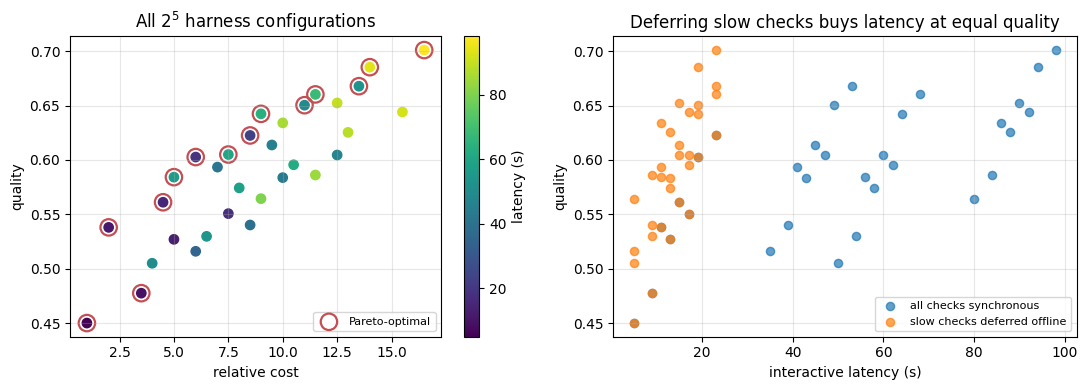

highest-quality config: q=0.701
  latency if fully synchronous : 98s
  latency with slow checks offline: 23s  (saves 75s)


In [7]:
fig, axes = plt.subplots(1, 2)

sc = axes[0].scatter(C, Q, c=L, cmap="viridis", s=45)
axes[0].scatter(C[front], Q[front], facecolors="none", edgecolors="#c44e52", s=140, lw=1.6,
                label="Pareto-optimal")
plt.colorbar(sc, ax=axes[0], label="latency (s)")
axes[0].set_xlabel("relative cost")
axes[0].set_ylabel("quality")
axes[0].set_title("All $2^5$ harness configurations")
axes[0].legend(fontsize=8, loc="lower right")

# The synchronous/asynchronous decision: same controls, latency paid or deferred
sync_only_lat = np.array([5.0 + sum(CONTROLS[n][2] for n, on in zip(names, c["mask"]) if on)
                          for c in configs])
deferred_lat = np.array([5.0 + sum(CONTROLS[n][2] for n, on in zip(names, c["mask"]) if on
                                   and CONTROLS[n][2] < 10.0) for c in configs])
axes[1].scatter(sync_only_lat, Q, s=35, alpha=0.7, label="all checks synchronous")
axes[1].scatter(deferred_lat, Q, s=35, alpha=0.7, label="slow checks deferred offline")
axes[1].set_xlabel("interactive latency (s)")
axes[1].set_ylabel("quality")
axes[1].set_title("Deferring slow checks buys latency at equal quality")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

i_best_q = int(np.argmax(Q))
saved = sync_only_lat[i_best_q] - deferred_lat[i_best_q]
print(f"highest-quality config: q={Q[i_best_q]:.3f}")
print(f"  latency if fully synchronous : {sync_only_lat[i_best_q]:.0f}s")
print(f"  latency with slow checks offline: {deferred_lat[i_best_q]:.0f}s  (saves {saved:.0f}s)")
assert saved > 0

**Result.** More than half of the 32 configurations are dominated — adding controls indiscriminately buys cost and
latency without buying quality, because gains saturate. The second panel is the survey's practical
prescription: the same quality is reachable at a fraction of the interactive latency by choosing which
checks are synchronous and which run offline in a regression suite.

## 4. The harness coupling problem

**Claim under test.** $\Delta_{\text{system}}(A \cup B) \neq \Delta(A) + \Delta(B)$. Two interventions
that each help in isolation can be worse together.

**Model.** A finite context budget. Intervention **A** (richer retrieval) improves the chance the needed
information is present but consumes tokens. Intervention **B** (stricter verifier) raises detection $d$
but each recovery attempt appends its own transcript, also consuming tokens. Success requires both
*having* the information and *not having crowded out* the working transcript.

In [8]:
DEFAULT_BUDGET = 100_000
BASE_TOKENS = 55_000          # transcript, tool schemas, instruction files
RETRIEVAL_A = 24_000          # richer retrieval payload, re-fetched on every attempt
RETRY_TOKENS = 16_000         # each recovery loop appends the failed attempt

P_INFO_BASE, P_INFO_A = 0.55, 0.85   # chance the needed info is in context
D_BASE, D_B = 0.20, 0.90             # detection probability
K = 4
CLIFF_U, CLIFF_S = 0.85, 25.0        # crowding sets in sharply past 85% of the window


def crowding_penalty(tokens_used, budget):
    """Quality holds until the working window is nearly full, then falls off a cliff."""
    u = np.asarray(tokens_used, dtype=float) / budget
    return 1.0 / (1.0 + np.exp(CLIFF_S * (u - CLIFF_U)))


def cell(use_a, use_b, budget=DEFAULT_BUDGET):
    p_info = P_INFO_A if use_a else P_INFO_BASE
    d = D_B if use_b else D_BASE

    # Expected attempts at this detection level; retrieval re-runs on each attempt
    # and every failed attempt leaves its transcript behind.
    r = (1.0 - p_info) * d
    attempts = float(expected_attempts(p_info, d, K))
    tokens_final = (BASE_TOKENS
                    + (RETRIEVAL_A * attempts if use_a else 0.0)
                    + RETRY_TOKENS * (attempts - 1.0))

    penalty = float(crowding_penalty(tokens_final, budget))
    per_attempt = float(np.clip(p_info * penalty, 0.0, 1.0))
    return {
        "P": float(p_success(per_attempt, d, K)),
        "tokens": tokens_final,
        "attempts": attempts,
        "penalty": penalty,
    }


base = cell(False, False)
only_a = cell(True, False)
only_b = cell(False, True)
both = cell(True, True)

print(f"{'config':<12} {'P(success)':>11} {'tokens':>9} {'attempts':>9} {'crowding':>9}")
for label, res in [("baseline", base), ("A only", only_a), ("B only", only_b), ("A + B", both)]:
    print(f"{label:<12} {res['P']:>11.3f} {res['tokens']:>9,.0f} "
          f"{res['attempts']:>9.2f} {res['penalty']:>9.2f}")

dA = only_a["P"] - base["P"]
dB = only_b["P"] - base["P"]
dAB = both["P"] - base["P"]
interaction = dAB - (dA + dB)

print()
print(f"delta(A)      = {dA:+.3f}")
print(f"delta(B)      = {dB:+.3f}")
print(f"additive pred = {dA + dB:+.3f}")
print(f"delta(A+B)    = {dAB:+.3f}")
print(f"interaction   = {interaction:+.3f}  <-- negative means the combination underperforms")

assert dA > 0 and dB > 0, "each intervention should help alone"
assert interaction < 0, "the coupling effect should be negative here"
assert dAB < max(dA, dB), "combination should be worse than the better single intervention"

config        P(success)    tokens  attempts  crowding
baseline           0.604    56,581      1.10      1.00
A only             0.701    80,237      1.03      0.77
B only             0.898    65,167      1.64      0.99
A + B              0.807    85,227      1.16      0.49

delta(A)      = +0.097
delta(B)      = +0.294
additive pred = +0.390
delta(A+B)    = +0.203
interaction   = -0.187  <-- negative means the combination underperforms


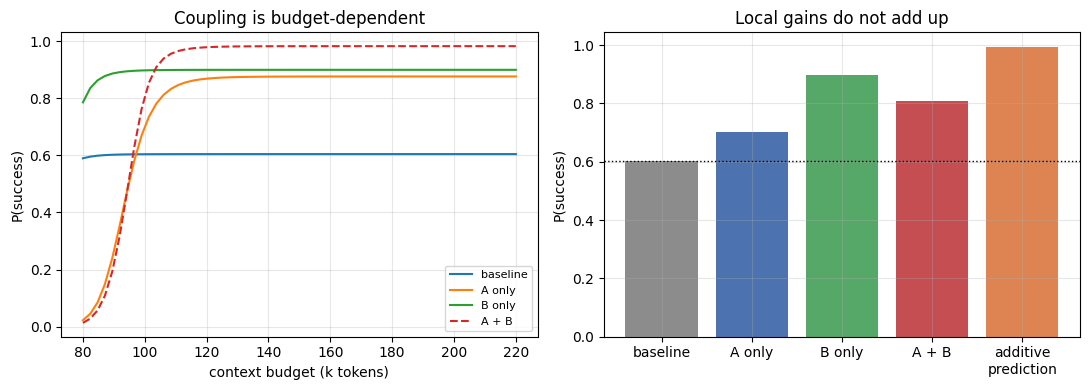

at a 220k budget the combination is best again: A+B=0.982 vs A=0.876, B=0.900


In [9]:
budgets = np.linspace(80_000, 220_000, 60)
curves = {
    "baseline": [cell(False, False, b)["P"] for b in budgets],
    "A only":   [cell(True,  False, b)["P"] for b in budgets],
    "B only":   [cell(False, True,  b)["P"] for b in budgets],
    "A + B":    [cell(True,  True,  b)["P"] for b in budgets],
}

fig, axes = plt.subplots(1, 2)
for label, ys in curves.items():
    style = "--" if label == "A + B" else "-"
    axes[0].plot(budgets / 1000, ys, style, label=label)
axes[0].set_xlabel("context budget (k tokens)")
axes[0].set_ylabel("P(success)")
axes[0].set_title("Coupling is budget-dependent")
axes[0].legend(fontsize=8)

labels = ["baseline", "A only", "B only", "A + B", "additive\nprediction"]
vals = [base["P"], only_a["P"], only_b["P"], both["P"], base["P"] + dA + dB]
colors = ["#8c8c8c", "#4c72b0", "#55a868", "#c44e52", "#dd8452"]
axes[1].bar(labels, vals, color=colors)
axes[1].axhline(base["P"], color="k", ls=":", lw=1)
axes[1].set_ylabel("P(success)")
axes[1].set_title("Local gains do not add up")

plt.tight_layout()
plt.show()

roomy = {k: v[-1] for k, v in curves.items()}
print(f"at a {budgets[-1]/1000:.0f}k budget the combination is best again: "
      f"A+B={roomy['A + B']:.3f} vs A={roomy['A only']:.3f}, B={roomy['B only']:.3f}")
assert roomy["A + B"] >= max(roomy["A only"], roomy["B only"]) - 1e-9

**Result.** At a tight context budget each intervention helps alone while the combination is worse than
either, and the additive prediction overstates the outcome by a large margin. Widen the budget and the
coupling disappears — which is why the effect is invisible in component benchmarks and shows up only in
full-system rollouts. This is the mechanism behind the survey's rule that harness changes must be tested
as system changes.

## 5. Code-graph retrieval economics

**Claim under test.** Graph expansion from lexical anchors buys recall at token cost that grows roughly
as $\bar{k}^{\,r}$, so confidence-filtered *local* expansion beats both flat search and deep expansion.

**Model.** A synthetic repository graph built by preferential attachment (hubs emerge, as in real
codebases). A task's ground-truth relevant set is a seed symbol plus its structural neighbours. Lexical
search finds some of the seeds plus noise; graph strategies expand $r$ hops from those anchors.

In [10]:
N_NODES = 600
M_EDGES = 2          # edges added per new node (mean out-degree ~ M_EDGES)
TOKENS_PER_NODE = 420

# --- build a directed graph by preferential attachment -------------------------
adj = [[] for _ in range(N_NODES)]
degree = np.ones(N_NODES)          # +1 smoothing for the attachment kernel
for v in range(M_EDGES, N_NODES):
    probs = degree[:v] / degree[:v].sum()
    targets = RNG.choice(v, size=min(M_EDGES, v), replace=False, p=probs)
    for t in targets:
        adj[v].append(int(t))      # v calls/imports t
        degree[t] += 1
        degree[v] += 1

# undirected adjacency for neighbourhood expansion (callers AND callees matter)
undirected = [set() for _ in range(N_NODES)]
for v, outs in enumerate(adj):
    for t in outs:
        undirected[v].add(t)
        undirected[t].add(v)

mean_deg = np.mean([len(s) for s in undirected])
print(f"graph: {N_NODES} nodes, mean undirected degree {mean_deg:.2f}")


def neighbourhood(seeds, r):
    seen = set(seeds)
    frontier = set(seeds)
    for _ in range(r):
        nxt = set()
        for v in frontier:
            nxt |= undirected[v]
        nxt -= seen
        seen |= nxt
        frontier = nxt
    return seen


# --- define tasks: ground truth = seed + its 1-hop structural neighbours -------
N_TASKS = 200
LEXICAL_RECALL = 0.55     # fraction of truth found by name matching
LEXICAL_NOISE = 3         # irrelevant files that match the keyword

tasks = []
for _ in range(N_TASKS):
    seed = int(RNG.integers(0, N_NODES))
    truth = neighbourhood([seed], 1)
    truth_list = sorted(truth)
    n_found = max(1, int(round(len(truth_list) * LEXICAL_RECALL)))
    anchors = set(RNG.choice(truth_list, size=n_found, replace=False).tolist())
    anchors |= set(RNG.integers(0, N_NODES, size=LEXICAL_NOISE).tolist())
    tasks.append({"truth": truth, "anchors": anchors})


def score(strategy):
    recalls, precisions, tokens = [], [], []
    for t in tasks:
        if strategy == "full repo dump":
            retrieved = set(range(N_NODES))
        elif strategy == "lexical only":
            retrieved = set(t["anchors"])
        else:
            r = int(strategy.split("=")[1])
            retrieved = neighbourhood(t["anchors"], r)
        hit = len(retrieved & t["truth"])
        recalls.append(hit / len(t["truth"]))
        precisions.append(hit / max(1, len(retrieved)))
        tokens.append(len(retrieved) * TOKENS_PER_NODE)
    return np.mean(recalls), np.mean(precisions), np.mean(tokens)


STRATEGIES = ["lexical only", "graph r=1", "graph r=2", "graph r=3", "full repo dump"]
results = {s: score(s) for s in STRATEGIES}

print(f"\n{'strategy':<16} {'recall':>8} {'precision':>10} {'tokens':>10} {'recall/1k tok':>14}")
for s, (rec, prec, tok) in results.items():
    print(f"{s:<16} {rec:>8.3f} {prec:>10.3f} {tok:>10,.0f} {rec/(tok/1000):>14.4f}")

rec_lex = results["lexical only"][0]
rec_r1 = results["graph r=1"][0]
tok_r1 = results["graph r=1"][2]
tok_full = results["full repo dump"][2]
print(f"\nr=1 expansion over lexical: recall {rec_lex:.3f} -> {rec_r1:.3f} "
      f"(+{(rec_r1-rec_lex)*100:.1f} pp)")
print(f"r=1 vs full dump: {tok_full/tok_r1:.1f}x fewer tokens")
assert rec_r1 > rec_lex, "one hop of structure should beat lexical alone"

graph: 600 nodes, mean undirected degree 3.99

strategy           recall  precision     tokens  recall/1k tok
lexical only        0.601      0.455      2,430         0.2475
graph r=1           0.940      0.140     14,196         0.0662
graph r=2           1.000      0.029     71,312         0.0140
graph r=3           1.000      0.010    189,412         0.0053
full repo dump      1.000      0.008    252,000         0.0040

r=1 expansion over lexical: recall 0.601 -> 0.940 (+33.8 pp)
r=1 vs full dump: 17.8x fewer tokens


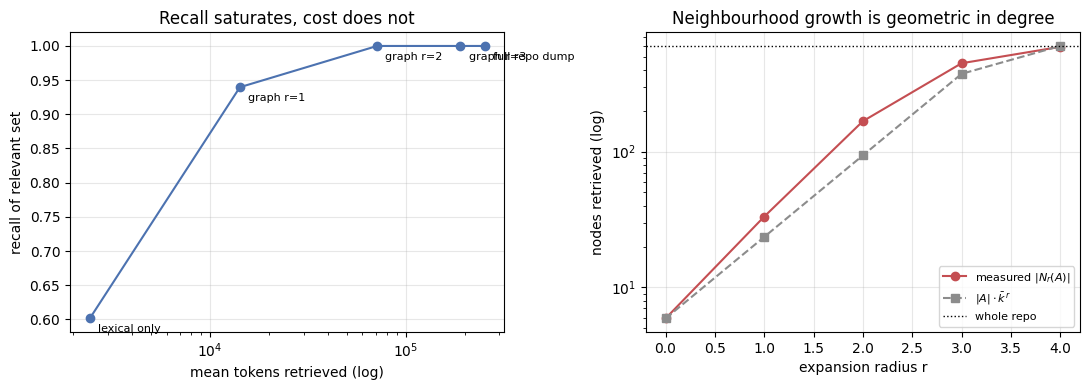

measured |N_r(A)|: ['6', '33', '168', '448', '591']
r=3 already retrieves 75% of the repository


In [11]:
fig, axes = plt.subplots(1, 2)

toks = [results[s][2] for s in STRATEGIES]
recs = [results[s][0] for s in STRATEGIES]
axes[0].plot(toks, recs, "o-", color="#4c72b0")
for s, x, y in zip(STRATEGIES, toks, recs):
    axes[0].annotate(s, (x, y), textcoords="offset points", xytext=(6, -10), fontsize=8)
axes[0].set_xscale("log")
axes[0].set_xlabel("mean tokens retrieved (log)")
axes[0].set_ylabel("recall of relevant set")
axes[0].set_title("Recall saturates, cost does not")

# empirical vs geometric prediction for neighbourhood growth
rs = [0, 1, 2, 3, 4]
sizes = [np.mean([len(neighbourhood(t["anchors"], r)) for t in tasks[:60]]) for r in rs]
a0 = sizes[0]
pred = [a0 * (mean_deg ** r) for r in rs]
axes[1].plot(rs, sizes, "o-", label="measured $|N_r(A)|$", color="#c44e52")
axes[1].plot(rs, np.clip(pred, 0, N_NODES), "s--", label=r"$|A|\cdot\bar{k}^{\,r}$", color="#8c8c8c")
axes[1].axhline(N_NODES, color="k", ls=":", lw=1, label="whole repo")
axes[1].set_yscale("log")
axes[1].set_xlabel("expansion radius r")
axes[1].set_ylabel("nodes retrieved (log)")
axes[1].set_title("Neighbourhood growth is geometric in degree")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("measured |N_r(A)|:", [f"{s:.0f}" for s in sizes])
print(f"r=3 already retrieves {sizes[3]/N_NODES:.0%} of the repository")

**Result.** One hop of structural expansion converts a partial lexical match into most of the relevant
set at a small fraction of a full dump — the mechanism behind LARGER's +11.8 to +13.9 Acc@5 and
Codebase-Memory's ~10x token reduction. Beyond $r=2$ the neighbourhood approaches the whole repository,
so recall gains stop while cost keeps compounding. That saturation is exactly why these systems use
*confidence-filtered local* expansion rather than deeper traversal.

## 6. Work-graph speedup ceiling

**Claim under test.** Multi-agent fan-out is capped by the critical path:
$T \ge \max(C, W/P)$ and $S_{\max} = W/C$. Declaring the work graph lets you compute the ceiling before
paying for agents.

**Model.** Layered random DAGs standing in for issue-to-PR workflows, plus a pure chain as a control.
Scheduling is greedy list scheduling with $P$ agents.

In [12]:
def make_layered_dag(layers, width, rng, dep_prob=0.6):
    """Nodes grouped in layers; edges only from layer i to i+1 (a plausible work graph)."""
    nodes, edges, layer_of = [], [], {}
    idx = 0
    prev = []
    for li in range(layers):
        w = max(1, int(rng.integers(1, width + 1)))
        cur = []
        for _ in range(w):
            nodes.append(idx)
            layer_of[idx] = li
            cur.append(idx)
            idx += 1
        for c in cur:
            if prev:
                picked = [p for p in prev if rng.random() < dep_prob] or [rng.choice(prev)]
                for p in picked:
                    edges.append((int(p), int(c)))
        prev = cur
    return nodes, edges, layer_of


def critical_path(nodes, edges, dur):
    succ = {n: [] for n in nodes}
    indeg = {n: 0 for n in nodes}
    for a, b in edges:
        succ[a].append(b)
        indeg[b] += 1
    order, stack = [], [n for n in nodes if indeg[n] == 0]
    indeg2 = dict(indeg)
    while stack:
        n = stack.pop()
        order.append(n)
        for s in succ[n]:
            indeg2[s] -= 1
            if indeg2[s] == 0:
                stack.append(s)
    longest = {n: dur[n] for n in nodes}
    for n in order:
        for s in succ[n]:
            longest[s] = max(longest[s], longest[n] + dur[s])
    return max(longest.values()), succ, indeg


def list_schedule(nodes, edges, dur, n_agents):
    _, succ, indeg = critical_path(nodes, edges, dur)
    remaining = dict(indeg)
    ready = [n for n in nodes if remaining[n] == 0]
    running = []          # (finish_time, node)
    t, done = 0.0, 0
    while done < len(nodes):
        while ready and len(running) < n_agents:
            n = ready.pop(0)
            running.append((t + dur[n], n))
        if not running:
            break
        running.sort()
        t, n = running.pop(0)
        done += 1
        for s in succ[n]:
            remaining[s] -= 1
            if remaining[s] == 0:
                ready.append(s)
    return t


rng = np.random.default_rng(11)
cases = {}

nodes, edges, _ = make_layered_dag(layers=6, width=5, rng=rng)
dur = {n: float(rng.uniform(1.0, 4.0)) for n in nodes}
cases["issue-to-PR (wide)"] = (nodes, edges, dur)

nodes2, edges2, _ = make_layered_dag(layers=12, width=2, rng=rng)
dur2 = {n: float(rng.uniform(1.0, 4.0)) for n in nodes2}
cases["deep pipeline"] = (nodes2, edges2, dur2)

chain_n = list(range(14))
chain_e = [(i, i + 1) for i in range(13)]
chain_d = {n: 2.5 for n in chain_n}
cases["pure chain"] = (chain_n, chain_e, chain_d)

agents = np.arange(1, 13)
print(f"{'work graph':<22} {'W':>7} {'C':>7} {'W/C':>6} {'T(1)':>7} {'T(8)':>7} {'speedup@8':>10}")
schedules = {}
for label, (nd, eg, du) in cases.items():
    W = sum(du.values())
    C, _, _ = critical_path(nd, eg, du)
    ts = np.array([list_schedule(nd, eg, du, p) for p in agents])
    schedules[label] = (W, C, ts)
    print(f"{label:<22} {W:>7.1f} {C:>7.1f} {W/C:>6.2f} {ts[0]:>7.1f} {ts[7]:>7.1f} "
          f"{ts[0]/ts[7]:>10.2f}x")
    assert ts.min() >= C - 1e-6, "no schedule may beat the critical path"

W_c, C_c, ts_c = schedules["pure chain"]
assert abs(ts_c[0] - ts_c[-1]) < 1e-6, "a chain cannot be accelerated by more agents"
print("\npure chain: 1 agent and 12 agents give identical makespan "
      f"({ts_c[0]:.1f} vs {ts_c[-1]:.1f}) - fan-out buys nothing")

work graph                   W       C    W/C    T(1)    T(8)  speedup@8
issue-to-PR (wide)        45.1    18.3   2.46    45.1    18.3       2.46x
deep pipeline             53.2    32.8   1.62    53.2    32.8       1.62x
pure chain                35.0    35.0   1.00    35.0    35.0       1.00x

pure chain: 1 agent and 12 agents give identical makespan (35.0 vs 35.0) - fan-out buys nothing


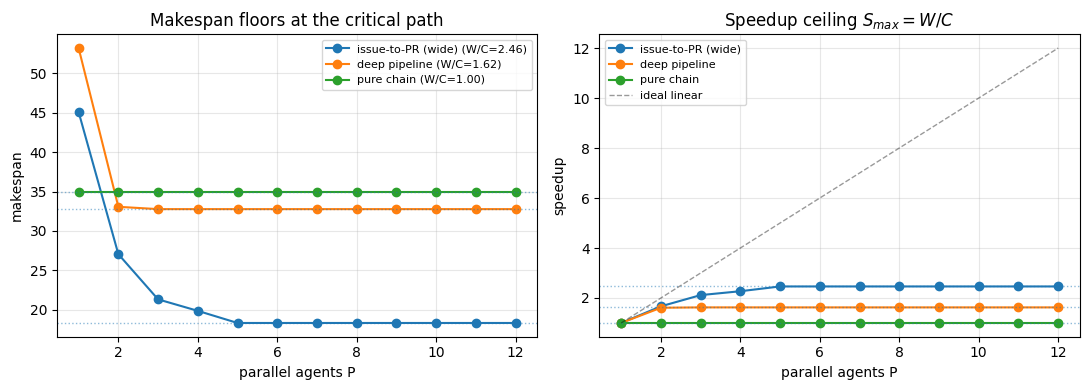

issue-to-PR (wide)     ceiling W/C= 2.46  achieved@12 agents= 2.46  agents worth adding: 3
deep pipeline          ceiling W/C= 1.62  achieved@12 agents= 1.62  agents worth adding: 2
pure chain             ceiling W/C= 1.00  achieved@12 agents= 1.00  agents worth adding: 1


In [13]:
fig, axes = plt.subplots(1, 2)

for label, (W, C, ts) in schedules.items():
    axes[0].plot(agents, ts, "o-", label=f"{label} (W/C={W/C:.2f})")
    axes[0].axhline(C, ls=":", lw=1, alpha=0.5)
axes[0].set_xlabel("parallel agents P")
axes[0].set_ylabel("makespan")
axes[0].set_title("Makespan floors at the critical path")
axes[0].legend(fontsize=8)

for label, (W, C, ts) in schedules.items():
    axes[1].plot(agents, ts[0] / ts, "o-", label=label)
    axes[1].axhline(W / C, ls=":", lw=1, alpha=0.5)
axes[1].plot(agents, agents, "k--", lw=1, alpha=0.4, label="ideal linear")
axes[1].set_xlabel("parallel agents P")
axes[1].set_ylabel("speedup")
axes[1].set_title(r"Speedup ceiling $S_{max}=W/C$")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

for label, (W, C, ts) in schedules.items():
    achieved = ts[0] / ts[-1]
    print(f"{label:<22} ceiling W/C={W/C:5.2f}  achieved@12 agents={achieved:5.2f}  "
          f"agents worth adding: {int(np.ceil(W/C))}")

**Result.** Every work graph has a computable ceiling. The wide issue-to-PR graph gains real parallelism;
the deep pipeline gains little; the chain gains exactly nothing regardless of agent count. The number of
agents worth provisioning is roughly $\lceil W/C \rceil$ — beyond that you pay for idle capacity. This
is the arithmetic behind the advisor-orchestrator result (~92% of solo quality at ~63% of cost): the win
comes from cheaper workers on parallelizable branches, not from more workers on a chain.

## Takeaways

1. **The harness is the bigger lever than you expect.** On fixed weights, layer composition moved pass@1
   several times more than a generational model upgrade in this model — matching the reported 6-29 pp
   harness spreads and the 58.8 pp collapse when a model is moved off its native harness. A benchmark
   number describes a model-harness *pair*.

2. **Guides and sensors are complements, and the split depends on retries.** With one attempt, spend on
   guides ($d$ is worthless without a chance to act on it). As the retry budget grows the optimum shifts
   toward sensors. Feedforward-only caps success at $p$; feedback-only pays $1/p$ attempts.

3. **Most harness configurations are dominated.** Of $2^5$ control combinations, only a handful were
   Pareto-optimal in (quality, cost, latency). The actionable move is scheduling, not addition: defer slow
   checks offline and reach the same quality at a fraction of interactive latency.

4. **Coupling is real and budget-dependent.** Two interventions that each helped alone were jointly worse
   than either under a tight context budget, with a strongly negative interaction term — and the effect
   vanished once the budget was widened. Component benchmarks cannot see this; only full-loop tests can.

5. **One hop of code graph is the sweet spot.** Expanding from lexical anchors by $r=1$ captured most of
   the relevant set at a small fraction of a full dump, while $r=3$ already pulled in a large share of the
   repository. Neighbourhood size grows geometrically in mean degree, which is why production systems use
   confidence-filtered local expansion.

6. **Check $W/C$ before buying agents.** Speedup is capped by the critical path: the wide work graph
   parallelized well, the deep one poorly, and the chain not at all. Provision about $\lceil W/C \rceil$
   agents and no more.

**The through-line:** every result above is a systems result, not a model result. None of these numbers
change if the model gets better, and all of them change if the software around it does — which is the
entire argument for treating the harness as an engineering discipline.

Full discussion and sources: [harness_and_graph_engineering.md](harness_and_graph_engineering.md).